In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vetrirah/customer")

print("Path to dataset files:", path)

100%|██████████| 105k/105k [00:00<00:00, 21.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vetrirah/customer/versions/1


In [3]:
df_train=pd.read_csv(path + "/Train.csv" , encoding='ISO-8859-1')
df_sample=pd.read_csv(path + "/sample_submission.csv" , encoding='ISO-8859-1')
df_test=pd.read_csv(path + "/Test.csv" , encoding='ISO-8859-1')

In [4]:
df_train

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


In [5]:
df_train.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [6]:
X = df_train.drop(columns=["Segmentation"])
y = df_train["Segmentation"]


In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
num_cols = ['Age', 'Work_Experience', 'Family_Size']

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder())
])

full_pipeline = ColumnTransformer([
    ('num_pipe', num_pipe, num_cols),
    ('cat_pipe', cat_pipe, cat_cols)
], remainder='drop')

X_train_transformed = pd.DataFrame(full_pipeline.fit_transform(X_train), columns=full_pipeline.get_feature_names_out())
X_test_transformed = pd.DataFrame(full_pipeline.transform(X_test), columns=full_pipeline.get_feature_names_out())
X_transformed = pd.DataFrame(full_pipeline.fit_transform(X), columns=full_pipeline.get_feature_names_out())

In [10]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
rnd_clf.fit(X_train_transformed, y_train)
rnd_clf.score(X_test_transformed, y_test)

0.516728624535316

In [11]:
from sklearn.decomposition import PCA # Principal Component Analysis

pca = PCA(n_components=2)
X2D = pca.fit_transform(X_transformed)
X2D.shape

(8068, 2)

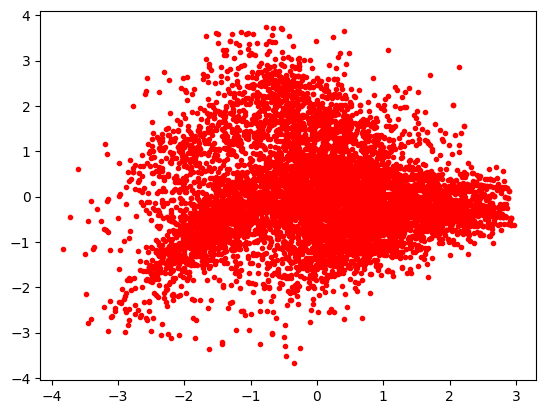

In [12]:
import matplotlib.pyplot as plt

plt.plot(X2D[:,0],X2D[:,1],"r.");
plt.show()

In [13]:
pca.explained_variance_ratio_

array([0.25384139, 0.17437737])

In [14]:
1 -  pca.explained_variance_ratio_.sum()

0.5717812392945947

#Choosing the right number of dimensions

In [15]:
pca = PCA()
pca.fit(X_transformed)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d=np.argmax(cumsum >= 0.95) + 1
d

14

In [16]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_transformed)

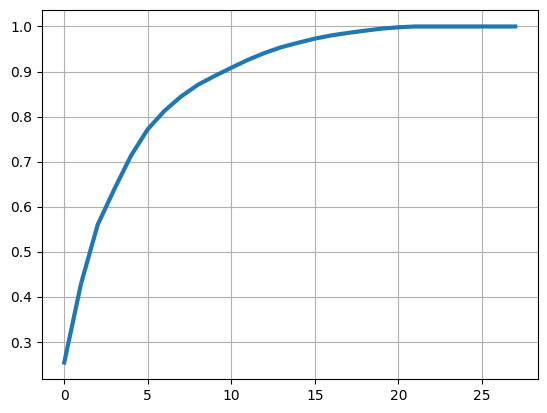

In [17]:
import matplotlib.pyplot as plt
plt.plot(cumsum,linewidth = 3)
plt.grid();

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import numpy as np
from sklearn.cluster import KMeans

num_cols = ['Age', 'Work_Experience', 'Family_Size']
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))  # sparse_output=False PCA ilə işləmək üçün
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

clf = make_pipeline(preprocessor,
                    PCA(random_state=42),
                    KMeans(random_state=42))
params = {
    'pca__n_components': np.arange(10, 29),
    'kmeans__n_clusters': np.arange(2, 10)
}


rnd_search = RandomizedSearchCV(clf, params, n_iter=10, cv=3, random_state=42)

rnd_search.fit(X_train[:1000], y_train[:1000])


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Work_Experience',
                                                                                'Family_Size']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_un...='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['Gender',
                                                                                'Ever_Married',
                                                                                'Graduated',
                                                                                'Profession',
                                                                                'Spending_Score',
                                                                                'Var_1'])])),
                                             ('pca', PCA(random_state=42)),
                                             ('kmeans',
                                              KMeans(random_state=42))]),
                   param_distributions={'kmeans__n_clusters': array([2, 3, 4, 5, 6, 7, 8, 9]),
                                        'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28])},
                   random_state=42)

In [32]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42,n_init=20)
y_pred = kmeans.fit_predict(X_transformed)

y_pred[:5]

array([2, 1, 0, 0, 1], dtype=int32)

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd


num_cols = ['Age', 'Work_Experience', 'Family_Size']
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

X_transformed = preprocessor.fit_transform(X)

# Now you can use X_transformed with KMeans
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X_transformed) for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

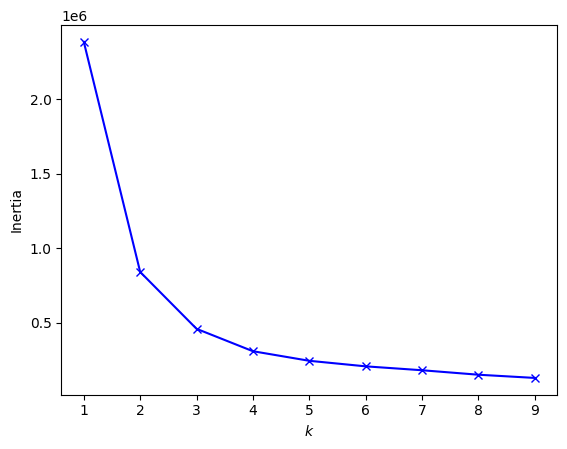

In [34]:
plt.plot(range(1,10),inertias, 'bx-')
plt.xlabel('$k$')
plt.ylabel('Inertia');
plt.show()

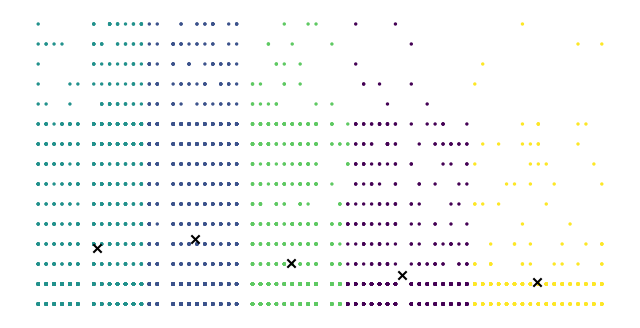

In [35]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=2)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='x')
    plt.axis('off')
    plt.show()

plt.figure(figsize=(8, 4))
plot_clusters(X_transformed, y_pred)